### Simulating an electrode cluster for a single participant 
- Simulating a small cluster of electrodes for a single participant 

### Imports

In [6]:
# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from simulate_cz_signal import generate_cz_signal

from specparam import SpectralModel
from specparam.plts import plot_spectra
from specparam.sim import sim_group_power_spectra

#### Data Simulation settings and Cz simulation

In [7]:
cz_signal = generate_cz_signal(seed=256, n_seconds=10, s_rate=250)

#### Simulating EEG-like signal for a cluster of 3 electrodes 


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



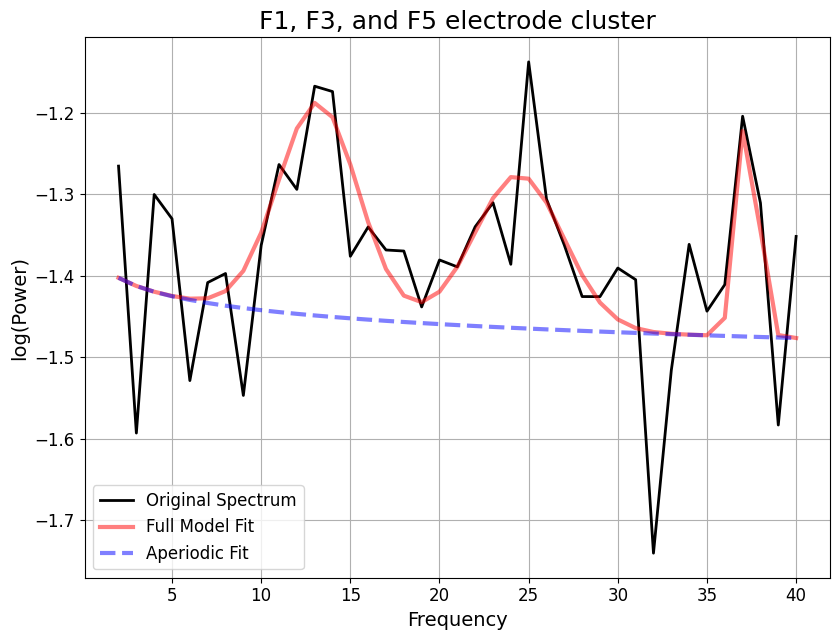

In [12]:
# Define correlations between Cz and specified electrodes
corr_factors = {
    'F1': 0.6,
    'F3': 0.6,
    'F5': 0.4}

# Generate signals for each electrode
electrode_signals = {}

for ele, rho in corr_factors.items():
        # scale noise to achieve desired correlation
        sigma_source = np.std(cz_signal)
        noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
        noise = noise_std * np.random.randn(len(cz_signal))
        electrode_signals[ele] = rho * cz_signal + noise

# Combine signals
signals_combined = np.mean(
    [electrode_signals['F1'],
     electrode_signals['F3'],
     electrode_signals['F5']],
    axis=0)

#Calculate power spectra
freqs, powers = compute_spectrum_welch(sig, fs = 250)

#Plot Spectral model for the three electrode cluster
fm_cluster = SpectralModel()
freq_range = [2, 40]
fm_cluster.fit(freqs, powers, freq_range)
fm_cluster.plot(title = "F1, F3, and F5 electrode cluster")